# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

# Data Processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import nltk
from nltk.corpus import stopwords

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Download NLTK Resource
nltk.download('stopwords')

# Plot Style
plt.style.use('ggplot')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
# ==========================================
# MEMUAT DATASET
# ==========================================

import os
import zipfile
from google.colab import files

# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json
print("Silakan upload file kaggle.json")
files.upload()

# Setup Kaggle API
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d jocelyndumlao/indonesia-presidential-candidates-dataset-2024

# Extract dataset
with zipfile.ZipFile(
    "indonesia-presidential-candidates-dataset-2024.zip",
    "r"
) as zip_ref:
    zip_ref.extractall("/content/dataset")

# Lokasi dataset
base_path = "/content/dataset/Indonesia Presidential Candidates Dataset, 2024/labeled data"

# Load dataset
anies = pd.read_csv(os.path.join(base_path, "Anies Baswedan.csv"))
ganjar = pd.read_csv(os.path.join(base_path, "Ganjar Pranowo.csv"))
prabowo = pd.read_csv(os.path.join(base_path, "Prabowo Subianto.csv"))

# Tambahkan kandidat
anies["Candidate"] = "Anies Baswedan"
ganjar["Candidate"] = "Ganjar Pranowo"
prabowo["Candidate"] = "Prabowo Subianto"

# Gabungkan
df = pd.concat(
    [anies, ganjar, prabowo],
    ignore_index=True
)

# Ambil kolom yang digunakan
df = df[["Text", "label", "Candidate"]]

print("Jumlah Data :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

display(df.head())

Silakan upload file kaggle.json


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jocelyndumlao/indonesia-presidential-candidates-dataset-2024
License(s): CC0-1.0
100% 6.81M/6.81M [00:01<00:00, 4.10MB/s]

Jumlah Data : 30000
Jumlah Kolom : 3


,Text,label,Candidate
0,anies president info,Positive,Anies Baswedan
1,gerindra party politician sandiaga uno answers...,Positive,Anies Baswedan
2,"mr. anies continued, we will guard him until h...",Positive,Anies Baswedan
3,may allah swt save the nation and state of the...,Positive,Anies Baswedan
4,"poor chotimah, uncle anies, that's why my fami...",Positive,Anies Baswedan


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

===== INFORMASI DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text       29731 non-null  object
 1   label      29997 non-null  object
 2   Candidate  30000 non-null  object
dtypes: object(3)
memory usage: 703.3+ KB
None

===== UKURAN DATASET =====
Jumlah Baris : 30000
Jumlah Kolom : 3

===== MISSING VALUE =====
Text         269
label          3
Candidate      0
dtype: int64

===== DISTRIBUSI LABEL =====
label
Positive    21654
Negative     8343
Name: count, dtype: int64

===== DISTRIBUSI KANDIDAT =====
Candidate
Anies Baswedan      10000
Ganjar Pranowo      10000
Prabowo Subianto    10000
Name: count, dtype: int64


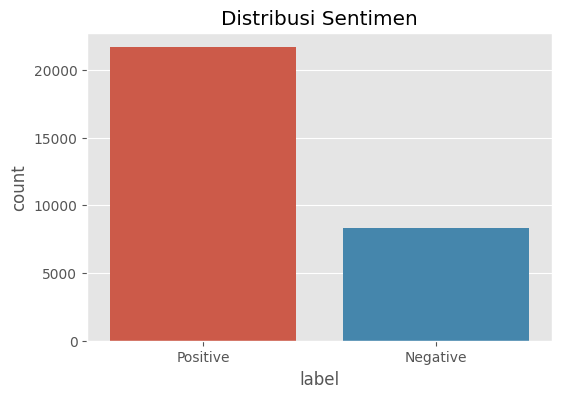

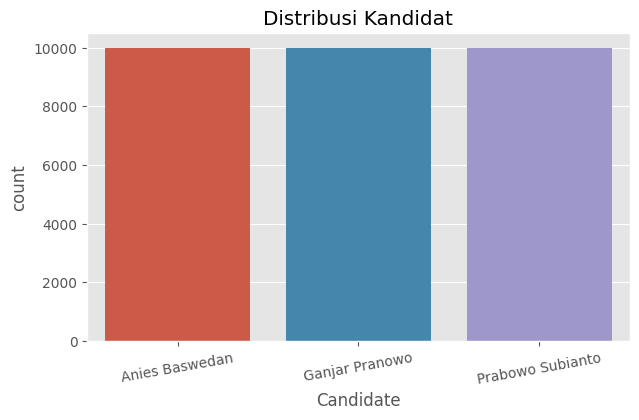

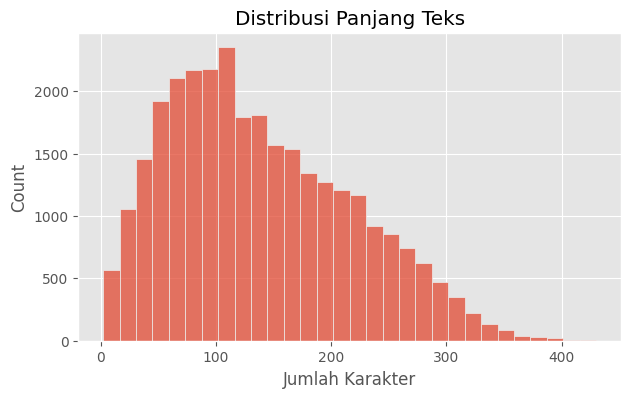


===== STATISTIK PANJANG TEKS =====
count    30000.000000
mean       138.639533
std         79.193611
min          2.000000
25%         76.000000
50%        126.000000
75%        195.000000
max        430.000000
Name: text_length, dtype: float64


In [5]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

print("===== INFORMASI DATASET =====")
print(df.info())

print("\n===== UKURAN DATASET =====")
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

print("\n===== MISSING VALUE =====")
print(df.isnull().sum())

print("\n===== DISTRIBUSI LABEL =====")
print(df["label"].value_counts())

print("\n===== DISTRIBUSI KANDIDAT =====")
print(df["Candidate"].value_counts())

# Visualisasi Distribusi Label
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="label",
    hue="label",
    legend=False
)
plt.title("Distribusi Sentimen")
plt.show()

# Visualisasi Distribusi Kandidat
plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x="Candidate",
    hue="Candidate",
    legend=False
)
plt.title("Distribusi Kandidat")
plt.xticks(rotation=10)
plt.show()

# Analisis panjang teks
df["text_length"] = df["Text"].astype(str).apply(len)

plt.figure(figsize=(7,4))
sns.histplot(df["text_length"], bins=30)
plt.title("Distribusi Panjang Teks")
plt.xlabel("Jumlah Karakter")
plt.show()

print("\n===== STATISTIK PANJANG TEKS =====")
print(df["text_length"].describe())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
# ==========================================
# DATA PREPROCESSING & MODELLING
# ==========================================

# Hapus missing value
df = df.dropna(subset=['Text', 'label'])

# Hapus duplikasi berdasarkan teks
df = df.drop_duplicates(subset=['Text'])

# Reset index
df = df.reset_index(drop=True)

# ------------------------------
# Text Cleaning
# ------------------------------

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    # Hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Hapus mention
    text = re.sub(r'@\w+', '', text)

    # Hapus hashtag
    text = re.sub(r'#', '', text)

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Hapus karakter selain huruf
    text = re.sub(r'[^\w\s]', '', text)

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # Stopword Removal
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_text"] = df["Text"].apply(clean_text)

# ------------------------------
# Label Encoding
# ------------------------------

encoder = LabelEncoder()

df["target"] = encoder.fit_transform(df["label"])

X = df["clean_text"]
y = df["target"]

# ------------------------------
# Train Test Split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------
# TF-IDF
# ------------------------------

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ------------------------------
# Logistic Regression
# ------------------------------

model = LogisticRegression(
    max_iter=3000,
    C=2.0,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_tfidf, y_train)

# ------------------------------
# Evaluasi Model
# ------------------------------

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("===== HASIL MODEL =====")
print(f"Akurasi : {accuracy:.4f}")

print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

# ------------------------------
# Inference
# ------------------------------

contoh = [
    "I really support this president because he works very well",
    "This president has disappointed the people"
]

contoh_clean = [clean_text(x) for x in contoh]

contoh_vector = tfidf.transform(contoh_clean)

hasil = model.predict(contoh_vector)

hasil_label = encoder.inverse_transform(hasil)

print("\n===== INFERENCE =====")

for i in range(len(contoh)):
    print(f"Teks      : {contoh[i]}")
    print(f"Prediksi  : {hasil_label[i]}")
    print()

# ------------------------------
# Simpan Dataset Preprocessing
# ------------------------------

dataset_final = df[["clean_text", "target"]]

dataset_final.to_csv(
    "dataset_preprocessing.csv",
    index=False
)

print("dataset_preprocessing.csv berhasil disimpan.")

===== HASIL MODEL =====
Akurasi : 0.8617

Classification Report

              precision    recall  f1-score   support

    Negative       0.70      0.87      0.77      1212
    Positive       0.95      0.86      0.90      3265

    accuracy                           0.86      4477
   macro avg       0.82      0.86      0.84      4477
weighted avg       0.88      0.86      0.87      4477


===== INFERENCE =====
Teks      : I really support this president because he works very well
Prediksi  : Positive

Teks      : This president has disappointed the people
Prediksi  : Negative

dataset_preprocessing.csv berhasil disimpan.
